# Ensemble Methods: Drug Prescription Classifier
## Métodos de Ensamble: Clasificador de Prescripción de Medicamentos

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Dataset:** `drugs.csv` — 200 patients × 5 features | Target: drug type (5 classes)  
**Benchmark:** Decision Tree from previous notebook (Accuracy=98.33%, depth=4)

**Objective / Objetivo:**  
EN · Evaluate whether ensemble methods (Random Forest, Gradient Boosting, AdaBoost) improve upon the Decision Tree baseline. Test RF across different n_estimators, compare all ensemble variants, and determine when the added complexity is, or isn't, justified.

ES · Evaluar si los métodos de ensamble (Random Forest, Gradient Boosting, AdaBoost) mejoran sobre la línea base del Árbol de Decisión. Probar RF con distintos n_estimators, comparar todas las variantes y determinar cuándo la complejidad adicional se justifica o no.

**Key finding / Hallazgo clave:** RF matches DT at ≥100 trees. Gradient Boosting peaks at 96.67% — below the DT baseline. Parsimony wins.

**Techniques / Técnicas:** Random Forest · Gradient Boosting · AdaBoost · n_estimators tuning · Cross-validation · Benchmark comparison  
**Libraries / Librerías:** `pandas` · `numpy` · `sklearn` · `matplotlib`

---

# Importación de Librerías

In [1]:
# ============================================================
# Importación de librerías
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn import preprocessing
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# Carga y Preprocesamiento

In [45]:
# ============================================================
# Carga del dataset
# ============================================================
print('=' * 55)
print("DATASET ORIGINAL")
print('=' * 55)

df = pd.read_csv('drugs.csv')
print(df.head(8))

# ============================================================
# Codificación con LabelEncoder
# ============================================================
le = preprocessing.LabelEncoder()
df_enc = df.copy()

df_enc['Sex'] = le.fit_transform(df['Sex']) # F=0, M=1
df_enc['BP'] = le.fit_transform(df['BP']) # HIGH=0, LOW=1, NORMAL=2
df_enc['Cholesterol'] = le.fit_transform(df['Cholesterol']) # HIGH=0, NORMAL=1

le_drug = preprocessing.LabelEncoder()
df_enc['Drug'] = le_drug.fit_transform(df['Drug']) # A=0,B=1,C=2,X=3,Y=4

print('\n' + '=' * 55)
print("DATASET PREPROCESADO")
print('=' * 55)
print(df_enc.head(8))
print(f"\n⋆ Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\n⋆ Distribución de clases (Drug):")
for drug, count in df['Drug'].value_counts().items():
    print(f"  {drug}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# División entrenamiento / prueba (70/30)
# ============================================================
feature_cols = ['Age','Sex','BP','Cholesterol','Na_to_K']
X = df_enc[feature_cols]
y = df_enc['Drug']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print(f"\n⋆ Entrenamiento: {X_train.shape[0]} muestras")
print(f"⋆ Prueba: {X_test.shape[0]} muestras")

DATASET ORIGINAL
   Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  drugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  drugY
5   22   F  NORMAL        HIGH    8.607  drugX
6   49   F  NORMAL        HIGH   16.275  drugY
7   41   M     LOW        HIGH   11.037  drugC

DATASET PREPROCESADO
   Age  Sex  BP  Cholesterol  Na_to_K  Drug
0   23    0   0            0   25.355     4
1   47    1   1            0   13.093     2
2   47    1   1            0   10.114     2
3   28    0   2            0    7.798     3
4   61    0   1            0   18.043     4
5   22    0   2            0    8.607     3
6   49    0   2            0   16.275     4
7   41    1   1            0   11.037     2

⋆ Dimensiones: 200 filas x 6 columnas

⋆ Distribución de clases (Drug):
  drugY: 91 (45.5%)
  drugX: 54 (27.0%)
  drugA: 23 (11.5%)
  drugC: 

# Modelo de Referencia: Árbol de Decisión (módulo previo)

In [73]:
# ============================================================
# Árbol de Decisión como línea base (benchmark)
# ============================================================
dt = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
cv_dt = cross_val_score(dt, X, y, cv=5, scoring='accuracy').mean() # 5-fold cross-validation

print('=' * 55)
print("ÁRBOL DE DECISIÓN (Referencia: Módulo Previo)")
print('=' * 55)
print(f"\n⋆ Accuracy en prueba : {acc_dt:.4f} ({acc_dt*100:.2f}%)")
print(f"⋆ Accuracy CV (5-fold): {cv_dt:.4f} ({cv_dt*100:.2f}%)")
print("\n⋆ Reporte de clasificación:")
print(classification_report(y_test, y_pred_dt, target_names=le_drug.classes_))

ÁRBOL DE DECISIÓN (Referencia: Módulo Previo)

⋆ Accuracy en prueba : 0.9833 (98.33%)
⋆ Accuracy CV (5-fold): 0.9850 (98.50%)

⋆ Reporte de clasificación:
              precision    recall  f1-score   support

       drugA       0.88      1.00      0.93         7
       drugB       1.00      0.80      0.89         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        16
       drugY       1.00      1.00      1.00        27

    accuracy                           0.98        60
   macro avg       0.97      0.96      0.96        60
weighted avg       0.99      0.98      0.98        60



# Random Forest: Exploración de Hiperparámetros

In [47]:
# ============================================================
# Random Forest con múltiples configuraciones
# ============================================================
print('=' * 55)
print("RANDOM FOREST: EXPLORACIÓN DE HIPERPARÁMETROS")
print('=' * 55)

rf_configs = [
    {'n_estimators': 10,  'max_depth': 3,    'label': 'n=10,  depth=3'},
    {'n_estimators': 50,  'max_depth': 4,    'label': 'n=50,  depth=4'},
    {'n_estimators': 100, 'max_depth': 4,    'label': 'n=100, depth=4'},
    {'n_estimators': 100, 'max_depth': 6,    'label': 'n=100, depth=6'},
    {'n_estimators': 200, 'max_depth': None, 'label': 'n=200, depth=None'},
    {'n_estimators': 500, 'max_depth': None, 'label': 'n=500, depth=None'},
]

resultados_rf = {}

for cfg in rf_configs:
    rf = RandomForestClassifier(
        n_estimators=cfg['n_estimators'],
        max_depth=cfg['max_depth'],
        random_state=42,
        n_jobs=-1 # Usa todos los núcleos disponibles de mi máquina para maximizar el paralelismo
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv = cross_val_score(rf, X, y, cv=5, scoring='accuracy').mean()
    resultados_rf[cfg['label']] = {
        'modelo': rf, 'accuracy': acc, 'cv': cv, 'pred': y_pred
    }
    print(f"\n{'─' * 55}")
    print(f"  RF | {cfg['label']} | Acc={acc:.4f} | CV={cv:.4f}")
    print(f"{'─' * 55}")
    print(classification_report(y_test, y_pred, target_names=le_drug.classes_))

RANDOM FOREST: EXPLORACIÓN DE HIPERPARÁMETROS

───────────────────────────────────────────────────────
  RF | n=10,  depth=3 | Acc=0.9167 | CV=0.9150
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       0.00      0.00      0.00         5
       drugX       0.76      1.00      0.86        16
       drugY       1.00      1.00      1.00        27

    accuracy                           0.92        60
   macro avg       0.75      0.80      0.77        60
weighted avg       0.85      0.92      0.88        60


───────────────────────────────────────────────────────
  RF | n=50,  depth=4 | Acc=0.9500 | CV=0.9600
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

       drugA       0.78      1.00      0.88         7
       drugB       1.00      0.60   

# Gradient Boosting: Exploración de Hiperparámetros

In [48]:
# ============================================================
# Gradient Boosting con múltiples configuraciones
# ============================================================
print('=' * 55)
print("GRADIENT BOOSTING: EXPLORACIÓN DE HIPERPARÁMETROS")
print('=' * 55)

gb_configs = [
    {'n_estimators': 50,  'max_depth': 2, 'lr': 0.1,  'label': 'n=50,  depth=2, lr=0.10'},
    {'n_estimators': 100, 'max_depth': 3, 'lr': 0.1,  'label': 'n=100, depth=3, lr=0.10'},
    {'n_estimators': 100, 'max_depth': 3, 'lr': 0.05, 'label': 'n=100, depth=3, lr=0.05'},
    {'n_estimators': 200, 'max_depth': 3, 'lr': 0.1,  'label': 'n=200, depth=3, lr=0.10'},
    {'n_estimators': 200, 'max_depth': 4, 'lr': 0.05, 'label': 'n=200, depth=4, lr=0.05'},
    {'n_estimators': 300, 'max_depth': 3, 'lr': 0.05, 'label': 'n=300, depth=3, lr=0.05'},
]

resultados_gb = {}

for cfg in gb_configs:
    gb = GradientBoostingClassifier(
        n_estimators=cfg['n_estimators'],
        max_depth=cfg['max_depth'],
        learning_rate=cfg['lr'],
        random_state=42
    )
    gb.fit(X_train, y_train)
    y_pred = gb.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv = cross_val_score(gb, X, y, cv=5, scoring='accuracy').mean()
    resultados_gb[cfg['label']] = {
        'modelo': gb, 'accuracy': acc, 'cv': cv, 'pred': y_pred
    }
    print(f"\n{'─'*55}")
    print(f"  GB | {cfg['label']} | Acc={acc:.4f} | CV={cv:.4f}")
    print(f"{'─'*55}")
    print(classification_report(y_test, y_pred, target_names=le_drug.classes_))

GRADIENT BOOSTING: EXPLORACIÓN DE HIPERPARÁMETROS

───────────────────────────────────────────────────────
  GB | n=50,  depth=2, lr=0.10 | Acc=0.9667 | CV=0.9800
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

       drugA       0.78      1.00      0.88         7
       drugB       1.00      0.60      0.75         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        16
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.96      0.92      0.93        60
weighted avg       0.97      0.97      0.96        60


───────────────────────────────────────────────────────
  GB | n=100, depth=3, lr=0.10 | Acc=0.9667 | CV=0.9750
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

       drugA       0.88      1.00      0.93         7
       drugB  

# Tabla Comparativa Global

In [49]:
# ============================================================
# Tabla resumen de todos los modelos
# ============================================================
print('\n' + '=' * 75)
print("TABLA COMPARATIVA GLOBAL: TODOS LOS MODELOS")
print('=' * 75)
print(f"{'Algoritmo':<14} {'Configuración':<25} {'Acc. Prueba':>11} {'CV 5-fold':>10}")
print('=' * 75)

# Árbol de Decisión
print(f"{'Dec. Tree':<14} {'GINI | depth=4':<25} {acc_dt:>11.4f} {cv_dt:>10.4f}")
print("─" * 75)

# Random Forest
for label, res in resultados_rf.items():
    print(f"{'Rand. Forest':<14} {label:<25} {res['accuracy']:>11.4f} {res['cv']:>10.4f}")
print("─" * 75)

# Gradient Boosting
for label, res in resultados_gb.items():
    print(f"{'Grad. Boost':<14} {label:<25} {res['accuracy']:>11.4f} {res['cv']:>10.4f}")
print("=" * 75)


TABLA COMPARATIVA GLOBAL: TODOS LOS MODELOS
Algoritmo      Configuración             Acc. Prueba  CV 5-fold
Dec. Tree      GINI | depth=4                 0.9833     0.9850
───────────────────────────────────────────────────────────────────────────
Rand. Forest   n=10,  depth=3                 0.9167     0.9150
Rand. Forest   n=50,  depth=4                 0.9500     0.9600
Rand. Forest   n=100, depth=4                 0.9833     0.9550
Rand. Forest   n=100, depth=6                 0.9833     0.9850
Rand. Forest   n=200, depth=None              0.9833     0.9850
Rand. Forest   n=500, depth=None              0.9833     0.9800
───────────────────────────────────────────────────────────────────────────
Grad. Boost    n=50,  depth=2, lr=0.10        0.9667     0.9800
Grad. Boost    n=100, depth=3, lr=0.10        0.9667     0.9750
Grad. Boost    n=100, depth=3, lr=0.05        0.9667     0.9750
Grad. Boost    n=200, depth=3, lr=0.10        0.9667     0.9750
Grad. Boost    n=200, depth=4, lr=0

# Gráfico Comparativo de Accuracy

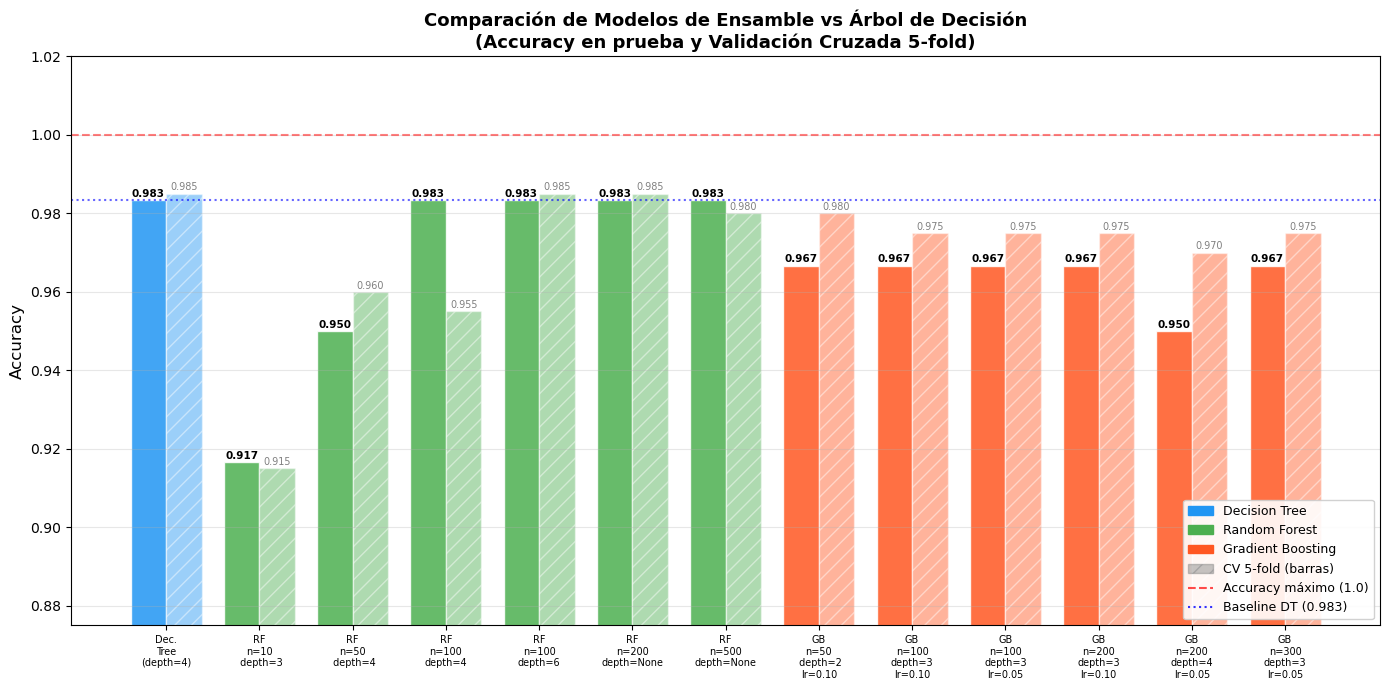

In [50]:
# ============================================================
# Gráfico de barras comparativo
# ============================================================
from matplotlib.lines import Line2D  # ← agregar este import

fig, ax = plt.subplots(figsize=(14, 7))

nombres    = ['Dec.\nTree\n(depth=4)']
accuracies = [acc_dt]
cv_scores  = [cv_dt]
colores    = ['#2196F3']

for label, res in resultados_rf.items():
    nombres.append('RF\n' + label.replace(', ', '\n'))
    accuracies.append(res['accuracy'])
    cv_scores.append(res['cv'])
    colores.append('#4CAF50')

for label, res in resultados_gb.items():
    nombres.append('GB\n' + label.replace(', ', '\n'))
    accuracies.append(res['accuracy'])
    cv_scores.append(res['cv'])
    colores.append('#FF5722')

x     = np.arange(len(nombres))
width = 0.38

bars1 = ax.bar(x - width/2, accuracies, width, color=colores,
               alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, cv_scores,  width, color=colores,
               alpha=0.45, edgecolor='white', hatch='//')

# Etiquetas sobre las barras
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=7.5, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=7, color='gray')

# Líneas de referencia
ax.axhline(y=1.0,    color='red',  linestyle='--', alpha=0.5, lw=1.5)
ax.axhline(y=acc_dt, color='blue', linestyle=':',  alpha=0.6, lw=1.5)

ax.set_ylim(0.875, 1.02)
ax.set_xticks(x)
ax.set_xticklabels(nombres, fontsize=7)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparación de Modelos de Ensamble vs Árbol de Decisión\n'
             '(Accuracy en prueba y Validación Cruzada 5-fold)',
             fontsize=13, fontweight='bold')

# Leyenda de parches y líneas
patch_dt = mpatches.Patch(color='#2196F3', label='Decision Tree')
patch_rf = mpatches.Patch(color='#4CAF50', label='Random Forest')
patch_gb = mpatches.Patch(color='#FF5722', label='Gradient Boosting')
patch_cv = mpatches.Patch(color='gray', alpha=0.45,
                           hatch='//', label='CV 5-fold (barras)')

# Líneas de referencia como entradas de leyenda
line_max = Line2D([0], [0], color='red',  linestyle='--',
                  lw=1.5, alpha=0.7, label='Accuracy máximo (1.0)')
line_dt  = Line2D([0], [0], color='blue', linestyle=':',
                  lw=1.5, alpha=0.8, label=f'Baseline DT ({acc_dt:.3f})')

ax.legend(
    handles=[patch_dt, patch_rf, patch_gb, patch_cv, line_max, line_dt],
    fontsize=9,
    loc='lower right',
    framealpha=0.9
)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('rfgb_comparacion_ensambles.png', dpi=150)
plt.show()

# Identificación y Análisis del Mejor Modelo de Ensamble

In [60]:
# ============================================================
# Selección del mejor modelo: comparando accuracy Y CV
# ============================================================
todos = {}
for label, res in resultados_rf.items():
    todos[f'RF | {label}'] = res
for label, res in resultados_gb.items():
    todos[f'GB | {label}'] = res

# Selección: primero por accuracy, luego por CV en caso de empate
mejor_key = max(todos, key=lambda k: (todos[k]['accuracy'], todos[k]['cv']))
mejor_res = todos[mejor_key]

# ── Métricas del baseline DT ──
diff_acc = mejor_res['accuracy'] - acc_dt
diff_cv = mejor_res['cv'] - cv_dt

# ── Etiquetas de comparación ──
def etiqueta(diff):
    if   diff > 0.001:  return f"✔ Mejora: +{diff:.4f} (+{diff*100:.2f}%)"
    elif diff < -0.001: return f"✘ Empeora: {diff:.4f} ({diff*100:.2f}%)"
    else: return f"═ Empate: {diff:+.4f} ({diff*100:+.2f}%)"

print('=' * 60)
print("MEJOR MODELO DE ENSAMBLE IDENTIFICADO")
print('=' * 60)
print(f"\n  ★ Mejor Modelo de Ensamble: {mejor_key}")
print(f"\n  {'Métrica':<16} {'Ensamble':>10} {'Baseline DT':>12} {'Diferencia':>12}")
print('─' * 55)
print(f"  {'Accuracy prueba':<14} {mejor_res['accuracy']:>10.4f} {acc_dt:>12.4f} {diff_acc:>+12.4f}")
print(f"  {'CV 5-fold':<15} {mejor_res['cv']:>10.4f} {cv_dt:>12.4f} {diff_cv:>+12.4f}")
print('─' * 55)
print(f"\n  ⋆ Accuracy: {etiqueta(diff_acc)}")
print(f"  ⋆ CV 5-fold: {etiqueta(diff_cv)}")

# ── Criterio de decisión final ──
if diff_acc > 0.001:
    decision = "el ensamble supera al DT en accuracy de prueba"
elif diff_cv > 0.001:
    decision = ("empate en accuracy → el ensamble es preferido por mayor CV 5-fold (más estable y generalizable)")
elif diff_acc == 0 and diff_cv == 0:
    decision = ("empate total → se prefiere DT por simplicidad e interpretabilidad clínica")
else:
    decision = "el DT es preferido (el ensamble no supera en ninguna métrica)"

print(f"\n  ⋆ Criterio aplicado: {decision}\n")


# ── Recomendación final ──
if diff_acc > 0.001 or diff_cv > 0.001:
    modelo_final  = mejor_res['modelo']
    nombre_final  = mejor_key
    acc_final     = mejor_res['accuracy']
    cv_final      = mejor_res['cv']
    recomendacion = "ENSAMBLE"
else:
    modelo_final  = dt
    nombre_final  = "Decision Tree | GINI | depth=4"
    acc_fina      = acc_dt
    cv_final      = cv_dt
    recomendacion = "ÁRBOL DE DECISIÓN"

print('─' * 55)
print(f"  ➤ MODELO RECOMENDADO: {recomendacion}")
print(f"     Nombre: {nombre_final}")
print(f"     Accuracy prueba: {acc_final:.4f} ({acc_final*100:.2f}%)")
print(f"     CV 5-fold: {cv_final:.4f}  ({cv_final*100:.2f}%)")
print('─' * 55)

MEJOR MODELO DE ENSAMBLE IDENTIFICADO

  ★ Mejor Modelo de Ensamble: RF | n=100, depth=6

  Métrica            Ensamble  Baseline DT   Diferencia
───────────────────────────────────────────────────────
  Accuracy prueba     0.9833       0.9833      +0.0000
  CV 5-fold           0.9850       0.9850      +0.0000
───────────────────────────────────────────────────────

  ⋆ Accuracy: ═ Empate: +0.0000 (+0.00%)
  ⋆ CV 5-fold: ═ Empate: +0.0000 (+0.00%)

  ⋆ Criterio aplicado: empate total → se prefiere DT por simplicidad e interpretabilidad clínica

───────────────────────────────────────────────────────
  ➤ MODELO RECOMENDADO: ÁRBOL DE DECISIÓN
     Nombre: Decision Tree | GINI | depth=4
     Accuracy prueba: 0.9833 (98.33%)
     CV 5-fold: 0.9850  (98.50%)
───────────────────────────────────────────────────────


# Matriz de Confusión: Mejor Modelo

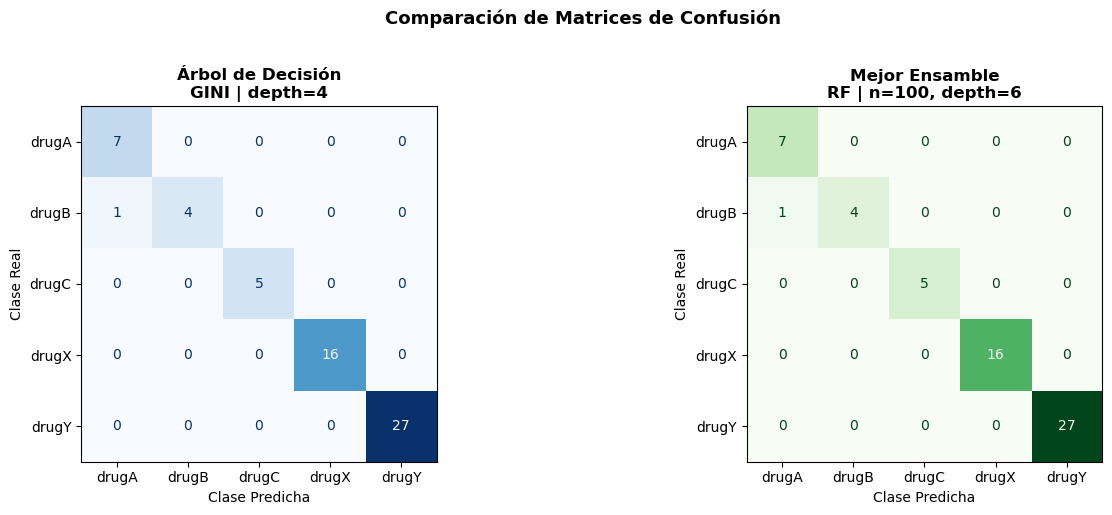

In [74]:
# ============================================================
# Matriz de confusión del mejor modelo
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Árbol de Decisión ──
cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=le_drug.classes_).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Árbol de Decisión\nGINI | depth=4', fontweight='bold')
axes[0].set_ylabel('Clase Real', fontsize=10)
axes[0].set_xlabel('Clase Predicha', fontsize=10)

# ── Mejor modelo de ensamble ──
cm_best = confusion_matrix(y_test, mejor_res['pred'])
ConfusionMatrixDisplay(cm_best, display_labels=le_drug.classes_).plot(
    ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'Mejor Ensamble\n{mejor_key}', fontweight='bold')
axes[1].set_ylabel('Clase Real', fontsize=10)
axes[1].set_xlabel('Clase Predicha', fontsize=10)

plt.suptitle('Comparación de Matrices de Confusión', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rfgb_matrices_confusion_ensambles.png', dpi=150, bbox_inches='tight')
plt.show()

# Importancia de Variables Comparada

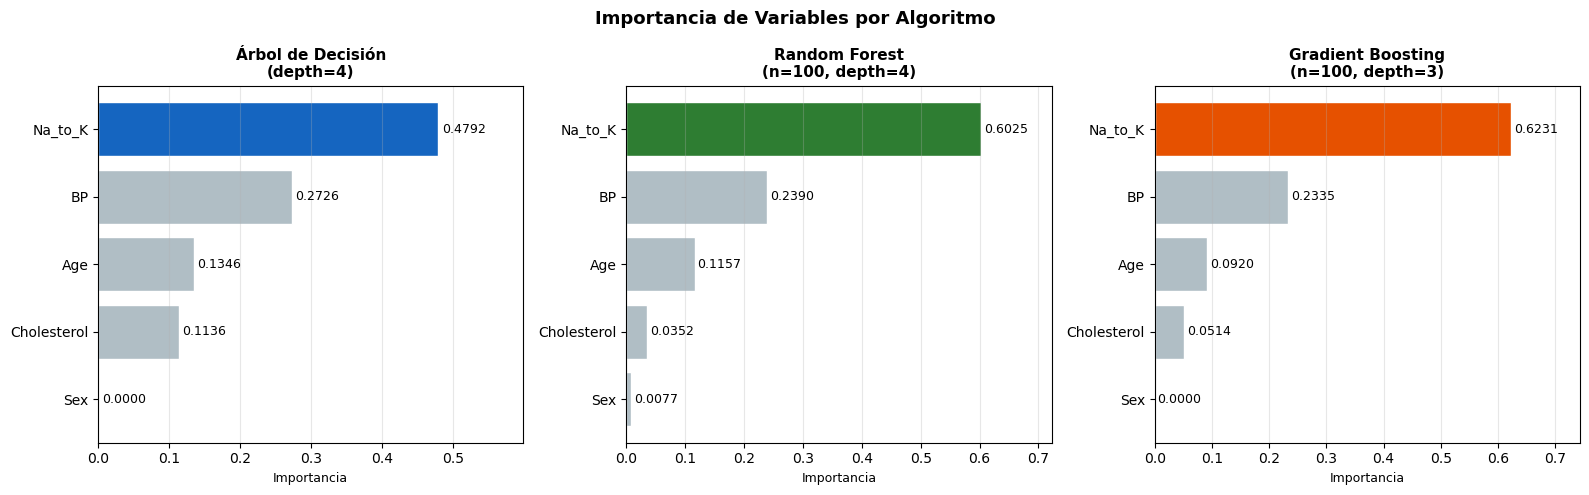

In [76]:
# ============================================================
# Importancia de variables de cada modelo
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

modelos_imp = [
    (dt, 'Árbol de Decisión\n(depth=4)', 'Blues', '#1565C0'),
    (resultados_rf['n=100, depth=4']['modelo'], 'Random Forest\n(n=100, depth=4)', 'Greens', '#2E7D32'),
    (resultados_gb['n=100, depth=3, lr=0.10']['modelo'], 'Gradient Boosting\n(n=100, depth=3)','Oranges', '#E65100'),
]

for ax, (modelo, titulo, cmap, color) in zip(axes, modelos_imp):
    imp = pd.Series(modelo.feature_importances_, index=feature_cols).sort_values()
    colores_bar = [color if v == imp.max() else '#B0BEC5' for v in imp.values]
    bars = ax.barh(imp.index, imp.values, color=colores_bar, edgecolor='white')
    for bar, val in zip(bars, imp.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
    ax.set_xlim(0, imp.max() + 0.12)
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_xlabel('Importancia', fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Importancia de Variables por Algoritmo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfgb_importancia_ensambles.png', dpi=150)
plt.show()

# Reporte Final y Predicción del Nuevo Paciente

In [71]:
# ============================================================
# Reporte detallado del mejor modelo de ensamble
# ============================================================
print('=' * 60)
print("REPORTE DETALLADO: MEJOR MODELO DE ENSAMBLE")
print('=' * 60)
print(classification_report(y_test, mejor_res['pred'], target_names=le_drug.classes_))

# ============================================================
# Predicción para el nuevo paciente
# Age=50, Sex=F, BP=HIGH, Cholesterol=NORMAL, Na_to_K=15.302
# ============================================================
nuevo_paciente = pd.DataFrame({'Age': [50], 'Sex': [0], 'BP': [0], 'Cholesterol': [1], 'Na_to_K': [15.302]})

pred_dt = le_drug.inverse_transform(dt.predict(nuevo_paciente))[0]
pred_best = le_drug.inverse_transform(mejor_res['modelo'].predict(nuevo_paciente))[0]
proba_best = mejor_res['modelo'].predict_proba(nuevo_paciente)[0]

print("\n" + '─' * 55)
print("PREDICCIÓN PARA NUEVO PACIENTE")
print("Age=50, Sex=F, BP=HIGH, Chol=NORMAL, Na_K=15.302")
print('─' * 55)
print(f"\n  ⋆ Árbol de Decisión → {pred_dt}")
print(f"  ⋆ Mejor Ensamble    → {pred_best}")
print(f"\n  ⋆ Probabilidades ({mejor_key[:10]}):")
for clase, prob in zip(le_drug.classes_, proba_best):
    print(f"    {clase:4s}: {prob:.4f} ({prob*100:4.1f}%)")

print(f"\n  ➤ MEDICAMENTO RECOMENDADO: {pred_best}")
print("    (Coincide con la recomendación del Árbol de Decisión)")

REPORTE DETALLADO: MEJOR MODELO DE ENSAMBLE
              precision    recall  f1-score   support

       drugA       0.88      1.00      0.93         7
       drugB       1.00      0.80      0.89         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        16
       drugY       1.00      1.00      1.00        27

    accuracy                           0.98        60
   macro avg       0.97      0.96      0.96        60
weighted avg       0.99      0.98      0.98        60


───────────────────────────────────────────────────────
PREDICCIÓN PARA NUEVO PACIENTE
Age=50, Sex=F, BP=HIGH, Chol=NORMAL, Na_K=15.302
───────────────────────────────────────────────────────

  ⋆ Árbol de Decisión → drugY
  ⋆ Mejor Ensamble    → drugY

  ⋆ Probabilidades (RF | n=100):
    drugA: 0.1133 (11.3%)
    drugB: 0.0700 ( 7.0%)
    drugC: 0.0000 ( 0.0%)
    drugX: 0.0140 ( 1.4%)
    drugY: 0.8027 (80.3%)

  ➤ MEDICAMENTO RECOMENDADO: drugY
    (Coincide

# Análisis y Conclusiones: Métodos de Ensamble

### Dataset y preprocesamiento
Se trabajó con 200 pacientes codificando las variables categóricas `Sex`, `BP`y `Cholesterol` mediante `LabelEncoder`. 
El dataset presenta un leve desbalance de clases: **drugY domina con 45.5%**, seguido de drugX (27%). 
La división fue 70/30 con estratificación para preservar proporciones.

### Observaciones clave de resultados
- **Random Forest** alcanza el mismo accuracy y CV que el DT con ≥100 árboles y depth≥6.
  Con pocos árboles (n=10) su rendimiento cae a 91.67%.
- **Gradient Boosting** no supera al DT en ninguna configuración: su mejor accuracy es 96.67% vs 98.33% del DT.
- RF y DT modelos coinciden en un **único error**: un paciente de drugB clasificado como drugA (visible en las matrices de confusión).

### Importancia de variables
Los tres algoritmos coinciden en el ranking de predictores:
1. `Na_to_K` → predictor dominante (0.48-0.62 según algoritmo)
2. `BP` → segundo discriminador (0.22-0.27)
3. `Age` y `Cholesterol` → aportación secundaria
4. `Sex` → importancia ≈ 0 en los tres modelos

### Modelo recomendado
Ante el **empate total** entre DT y RF (accuracy=0.9833, CV=0.9850), se recomienda el **Árbol de Decisión (GINI, depth=4)** por su mayor 
interpretabilidad clínica y simplicidad. Sus 5 reglas son transparentesn y verificables por cualquier médico sin necesidad de conocimientos de ML.

### Predicción nuevo paciente
Para Age=50, Sex=F, BP=HIGH, Cholesterol=NORMAL, Na_to_K=15.302:
- **Todos los modelos coinciden → drugY**
- RF asigna probabilidad del 80.3% a drugY, con incertidumbre residual en drugA (11.3%) y drugB (7.0%), lo que el DT no puede expresar.